# Results and Figures


In [1]:
import os, sys, pickle, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch

from src.features import build_features, TIER_COLUMNS, feature_set, parse_freeze_frame, parse_location
from src.models import load_features, split

sns.set_style('white')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})


In [2]:
results = pd.read_csv('results/all_models.csv')
with open('models/xgboost_tuned.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
print(f'Leaderboard rows: {len(results)}')
print(f'Tuned XGBoost (n_features: {xgb_model.n_features_in_})')


Leaderboard rows: 21
Tuned XGBoost (n_features: 57)


## Main comparison table

In [3]:
def _format(r):
    return {
        'Model'     : r['model'],
        'Tier'      : r['tier'],
        '# features': int(r['n_features']),
        'AUC-ROC'   : round(r['auc_roc'], 4),
        'Log Loss'  : round(r['log_loss'], 4),
        'Brier'     : round(r['brier'], 4),
    }

best_per_model = (results.sort_values('log_loss').groupby('model', as_index=False).first())
best_per_model = best_per_model.sort_values('log_loss')

main_table = pd.DataFrame([_format(r) for _, r in best_per_model.iterrows()])
print(main_table.to_string(index=False))
main_table.to_csv('results/table_main_comparison.csv', index=False)

              Model                 Tier  # features  AUC-ROC  Log Loss  Brier
    XGBoost (tuned) Tier 1+2+3+4+5 (all)          57   0.8123    0.2582 0.0734
 XGBoost + Isotonic Tier 1+2+3+4+5 (all)          57   0.8128    0.2587 0.0735
  XGBoost (vanilla) Tier 1+2+3+4+5 (all)          57   0.8108    0.2591 0.0735
      Random Forest Tier 1+2+3+4+5 (all)          57   0.8101    0.2596 0.0738
Logistic Regression Tier 1+2+3+4+5 (all)          61   0.8045    0.2625 0.0744
    XGBoost + Platt Tier 1+2+3+4+5 (all)          57   0.8126    0.2643 0.0744
      Decision Tree Tier 1+2+3+4+5 (all)          57   0.7907    0.2799 0.0760
        Naive Bayes Tier 1+2+3+4+5 (all)          57   0.7625    1.8267 0.1497


## Tier ablation table

In [4]:
xgb_abl = results[(results['model'] == 'XGBoost (tuned)')].copy()

tier_order = [
    'Tier 1 only (geometry)',
    'Tier 1+2',
    'Tier 1+2+3 (GK)',
    'Tier 1+2+3+4 (freeze frame)',
    'Tier 1+2+3+4+5 (all)',
]
xgb_abl = xgb_abl.set_index('tier').reindex(tier_order).reset_index()
xgb_abl['Δ log loss'] = xgb_abl['log_loss'].diff().round(4)
xgb_abl['Δ AUC'] = xgb_abl['auc_roc'].diff().round(4)

display_cols = ['tier', 'n_features', 'auc_roc', 'log_loss', 'brier', 'Δ AUC', 'Δ log loss']
xgb_abl_display = xgb_abl[display_cols].round(4)
print(xgb_abl_display.to_string(index=False))
xgb_abl_display.to_csv('results/table_ablation_xgboost.csv', index=False)


                       tier  n_features  auc_roc  log_loss  brier  Δ AUC  Δ log loss
     Tier 1 only (geometry)           2   0.7392    0.2906 0.0826    NaN         NaN
                   Tier 1+2          32   0.7873    0.2720 0.0775 0.0481     -0.0186
            Tier 1+2+3 (GK)          39   0.8023    0.2643 0.0753 0.0150     -0.0077
Tier 1+2+3+4 (freeze frame)          47   0.8112    0.2593 0.0738 0.0088     -0.0050
       Tier 1+2+3+4+5 (all)          57   0.8123    0.2582 0.0734 0.0012     -0.0011


In [5]:
total_gain = xgb_abl.iloc[0]['log_loss'] - xgb_abl.iloc[-1]['log_loss']
print(f'Total log-loss improvement from geometry to all 5 tiers: {total_gain:.4f}\n')

print('Contribution by tier added:')
for i in range(1, len(xgb_abl)):
    delta = xgb_abl.iloc[i-1]['log_loss'] - xgb_abl.iloc[i]['log_loss']
    pct = 100 * delta / total_gain
    print(f'  + {xgb_abl.iloc[i]["tier"]:<32s}  Δ = -{delta:.4f}  ({pct:4.1f}%)')

novel_gain = sum(xgb_abl.iloc[i-1]['log_loss'] - xgb_abl.iloc[i]['log_loss'] for i in [2, 3, 4] if i < len(xgb_abl))
print(f'\nNovel-tier contribution (T3+T4+T5): {100*novel_gain/total_gain:.1f}% of total gain')


Total log-loss improvement from geometry to all 5 tiers: 0.0324

Contribution by tier added:
  + Tier 1+2                          Δ = -0.0186  (57.5%)
  + Tier 1+2+3 (GK)                   Δ = -0.0077  (23.8%)
  + Tier 1+2+3+4 (freeze frame)       Δ = -0.0050  (15.5%)
  + Tier 1+2+3+4+5 (all)              Δ = -0.0011  ( 3.3%)

Novel-tier contribution (T3+T4+T5): 42.5% of total gain


## Calibration figure


In [6]:
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = load_features()
train, test = split(df)
T12345 = feature_set('tier1', 'tier2', 'tier3', 'tier4', 'tier5')

proba_xgb = xgb_model.predict_proba(test[T12345])[:, 1]

lr = Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(C=1.0, max_iter=2000))])
lr.fit(train[T12345], train['goal'])
proba_lr = lr.predict_proba(test[T12345])[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(train[T12345], train['goal'])
proba_rf = rf.predict_proba(test[T12345])[:, 1]

with open('models/xgboost_isotonic.pkl', 'rb') as f:
    xgb_iso = pickle.load(f)
proba_iso = xgb_iso.predict_proba(test[T12345])[:, 1]

y_test = test['goal'].values

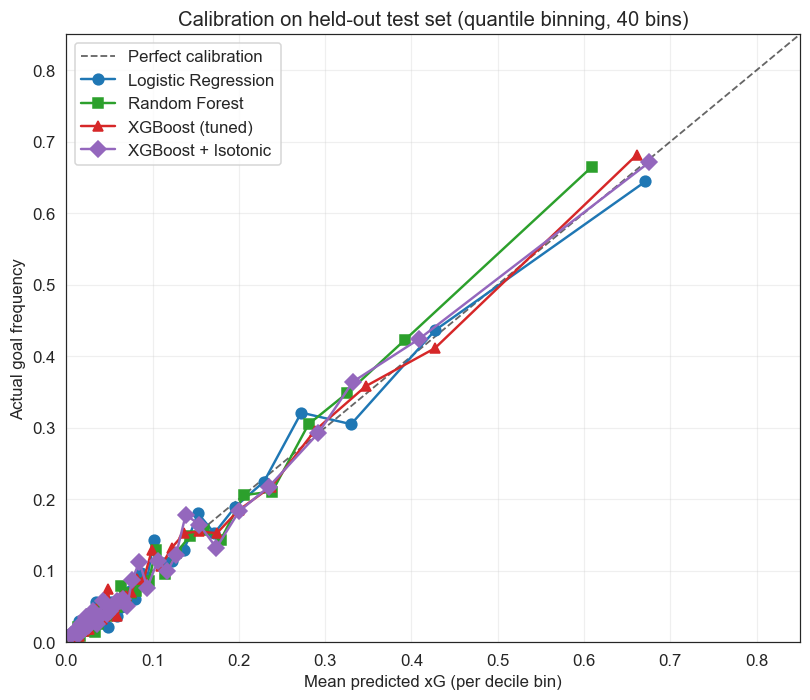

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, lw=1.2, label='Perfect calibration')

curves = [
    ('Logistic Regression', proba_lr,  '#1f77b4', 'o'),
    ('Random Forest', proba_rf,  '#2ca02c', 's'),
    ('XGBoost (tuned)', proba_xgb, '#d62728', '^'),
    ('XGBoost + Isotonic', proba_iso, '#9467bd', 'D'),
]

for name, p, color, mk in curves:
    prob_true, prob_pred = calibration_curve(y_test, p, n_bins=40, strategy='quantile')
    ax.plot(prob_pred, prob_true, color=color, marker=mk, lw=1.6, ms=7, label=name)

ax.set_xlabel('Mean predicted xG (per decile bin)')
ax.set_ylabel('Actual goal frequency')
ax.set_title('Calibration on held-out test set (quantile binning, 40 bins)')
ax.legend(loc='upper left', frameon=True)
ax.set_xlim(0, 0.85); ax.set_ylim(0, 0.85)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/05_calibration_final.png', dpi=160, bbox_inches='tight')
plt.show()

## Feature importance figure

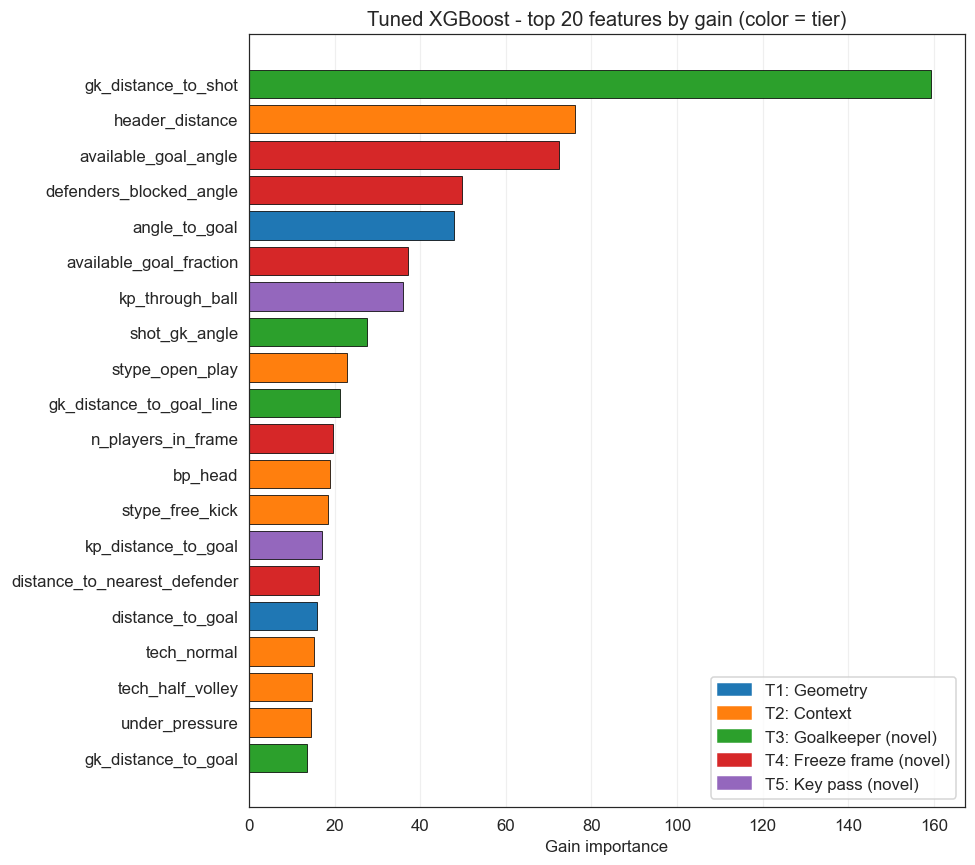

In [8]:
booster = xgb_model.get_booster()
imp = pd.Series(booster.get_score(importance_type='gain')).sort_values(ascending=False)
top = imp.head(20)

def tier_of(col):
    for t in ['tier5', 'tier4', 'tier3', 'tier2', 'tier1']:
        if col in TIER_COLUMNS[t]:
            return t
    return 'other'

TIER_COLORS = {
    'tier1': '#1f77b4',
    'tier2': '#ff7f0e',
    'tier3': '#2ca02c',
    'tier4': '#d62728',
    'tier5': '#9467bd',
}
TIER_LABELS = {
    'tier1': 'T1: Geometry',
    'tier2': 'T2: Context',
    'tier3': 'T3: Goalkeeper (novel)',
    'tier4': 'T4: Freeze frame (novel)',
    'tier5': 'T5: Key pass (novel)',
}

colors = [TIER_COLORS[tier_of(c)] for c in top.index]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1], edgecolor='black', lw=0.5)
ax.set_xlabel('Gain importance')
ax.set_title('Tuned XGBoost - top 20 features by gain (color = tier)')
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=TIER_COLORS[t], label=TIER_LABELS[t]) for t in TIER_LABELS]
ax.legend(handles=patches, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('figures/05_feature_importance_final.png', dpi=160, bbox_inches='tight')
plt.show()


In [9]:
tier_imp = {t: 0.0 for t in TIER_COLUMNS}
for feat, score in imp.items():
    t = tier_of(feat)
    if t in tier_imp:
        tier_imp[t] += score

tier_imp_pct = pd.Series(tier_imp) / sum(tier_imp.values()) * 100
print('Total gain attributable to each tier:')
for t, pct in tier_imp_pct.items():
    print(f'  {TIER_LABELS[t]:<35s}  {pct:5.1f}%')


Total gain attributable to each tier:
  T1: Geometry                           6.9%
  T2: Context                           31.3%
  T3: Goalkeeper (novel)                26.6%
  T4: Freeze frame (novel)              23.5%
  T5: Key pass (novel)                  11.8%


## Specific Examples

In [10]:
test_pred = test.copy()
test_pred['xg'] = proba_xgb
test_pred['xg_iso'] = proba_iso
test_pred['kp_location'] = test_pred['kp_location'].apply(parse_location)
test_pred['shot.freeze_frame'] = test_pred['shot.freeze_frame'].apply(parse_freeze_frame)

def shot_summary_cols(df):
    return df[[
        'player.name', 'shot.outcome.name', 'shot.body_part.name',
        'distance_to_goal', 'angle_to_goal',
        'gk_distance_to_goal_line', 'available_goal_fraction',
        'defenders_in_cone', 'xg', 'goal'
    ]].round(3)


### Case 1: High xG, no goal

Scenarios where the keeper made a great save, or the striker completely missed the target when they should have scored.

In [11]:
high_xg_misses = (test_pred[(test_pred['xg'] > 0.60) & (test_pred['goal'] == 0)].sort_values('xg', ascending=False).head(8))
print(f'Shots with xG > 0.60 that did NOT result in a goal: {len(test_pred[(test_pred["xg"]>0.60) & (test_pred["goal"]==0)])}\n')
print(shot_summary_cols(high_xg_misses).to_string())


Shots with xG > 0.60 that did NOT result in a goal: 54

                                  player.name shot.outcome.name shot.body_part.name  distance_to_goal  angle_to_goal  gk_distance_to_goal_line  available_goal_fraction  defenders_in_cone     xg  goal
61902                    Jesús Navas González             Off T           Left Foot             8.147         44.093                      11.6                      1.0                  0  0.891     0
36681             Deyverson Brum Silva Acosta              Post           Left Foot             7.910         53.615                      10.0                      1.0                  0  0.890     0
13564  Dominique Johanna Anna Petrone Janssen           Blocked           Left Foot             2.500        180.000                       0.4                      1.0                  0  0.864     0
12438                        Vivianne Miedema             Saved          Right Foot             2.236        143.973                       0.0  

### Case 2: Low xG, goal

When the player does really well to strike the ball from long range / tight angle

In [12]:
low_xg_goals = (test_pred[(test_pred['xg'] < 0.03) & (test_pred['goal'] == 1)].sort_values('xg', ascending=True).head(8))
print(f'Goals scored from shots the model rated < 0.03: {len(test_pred[(test_pred["xg"]<0.03) & (test_pred["goal"]==1)])}\n')
print(shot_summary_cols(low_xg_goals).to_string())


Goals scored from shots the model rated < 0.03: 105

                     player.name shot.outcome.name shot.body_part.name  distance_to_goal  angle_to_goal  gk_distance_to_goal_line  available_goal_fraction  defenders_in_cone     xg  goal
16151                  Lucy Hope              Goal          Right Foot            34.455         12.218                       1.4                    0.585                  0  0.009     1
62661          Rhu-endly Martina              Goal          Right Foot            31.723         13.097                       2.4                    0.554                  1  0.009     1
43869   Pablo Ezequiel De Blasis              Goal          Right Foot            39.684         11.064                      13.0                    0.888                  0  0.010     1
49341                Atila Turan              Goal           Left Foot            40.478         10.202                       1.2                    0.710                  0  0.010     1
45167       

### Case 3: Two similar shots, different keeper, different xG

To test the usefulness of GK features. We can bucket the shots by distance and angle see the range of xGs


In [13]:
work = test_pred.copy()
work['d_bucket']  = pd.cut(work['distance_to_goal'], bins=[8, 12, 16, 20, 25])
work['a_bucket']  = pd.cut(work['angle_to_goal'],   bins=[10, 20, 30, 45, 70])

candidates = []
for (d, a, bp), grp in work.groupby(['d_bucket', 'a_bucket', 'shot.body_part.name'], observed=True):
    if len(grp) < 30:
        continue

    lo = grp.nsmallest(1, 'available_goal_fraction').iloc[0]
    hi = grp.nlargest(1, 'available_goal_fraction').iloc[0]
    candidates.append({
        'distance':  d, 'angle': a, 'body_part': bp, 'n_in_bucket': len(grp),
        'low_avail_xg':  lo['xg'], 'high_avail_xg': hi['xg'],
        'xg_gap': hi['xg'] - lo['xg'],
        'low_idx':  lo.name, 'high_idx': hi.name,
    })

cand_df = pd.DataFrame(candidates).sort_values('xg_gap', ascending=False)
print('Top buckets by xG gap (low-avail vs high-avail GK situation):')
print(cand_df.head(5)[['distance', 'angle', 'body_part', 'n_in_bucket',
                       'low_avail_xg', 'high_avail_xg', 'xg_gap']].to_string(index=False))

pair = cand_df.iloc[0]
shot_lo = test_pred.loc[pair['low_idx']]
shot_hi = test_pred.loc[pair['high_idx']]
print(f'\n=== Selected pair (bucket: {pair["distance"]} × {pair["angle"]} × {pair["body_part"]}) ===')
print(f'\nShot A (GK exposed): xG={shot_lo["xg"]:.3f}, outcome={shot_lo["shot.outcome.name"]}')
print(f'  Distance {shot_lo["distance_to_goal"]:.1f}m, angle {shot_lo["angle_to_goal"]:.1f}°, available_goal_fraction={shot_lo["available_goal_fraction"]:.3f}')
print(f'\nShot B (GK covering):xG={shot_hi["xg"]:.3f}, outcome={shot_hi["shot.outcome.name"]}')
print(f'  Distance {shot_hi["distance_to_goal"]:.1f}m, angle {shot_hi["angle_to_goal"]:.1f}°, available_goal_fraction={shot_hi["available_goal_fraction"]:.3f}')


Top buckets by xG gap (low-avail vs high-avail GK situation):
distance    angle  body_part  n_in_bucket  low_avail_xg  high_avail_xg   xg_gap
 (8, 12] (30, 45]  Left Foot          290      0.033994       0.890988 0.856994
(12, 16] (20, 30] Right Foot          667      0.072112       0.825412 0.753300
(12, 16] (20, 30]  Left Foot          438      0.038098       0.772229 0.734131
 (8, 12] (45, 70]  Left Foot           62      0.122958       0.855160 0.732202
 (8, 12] (10, 20] Right Foot           58      0.047050       0.709586 0.662536

=== Selected pair (bucket: (8, 12] × (30, 45] × Left Foot) ===

Shot A (GK exposed): xG=0.034, outcome=Saved
  Distance 10.0m, angle 39.4°, available_goal_fraction=0.000

Shot B (GK covering):xG=0.891, outcome=Off T
  Distance 8.1m, angle 44.1°, available_goal_fraction=1.000


### Visualizing Case 3 on the pitch

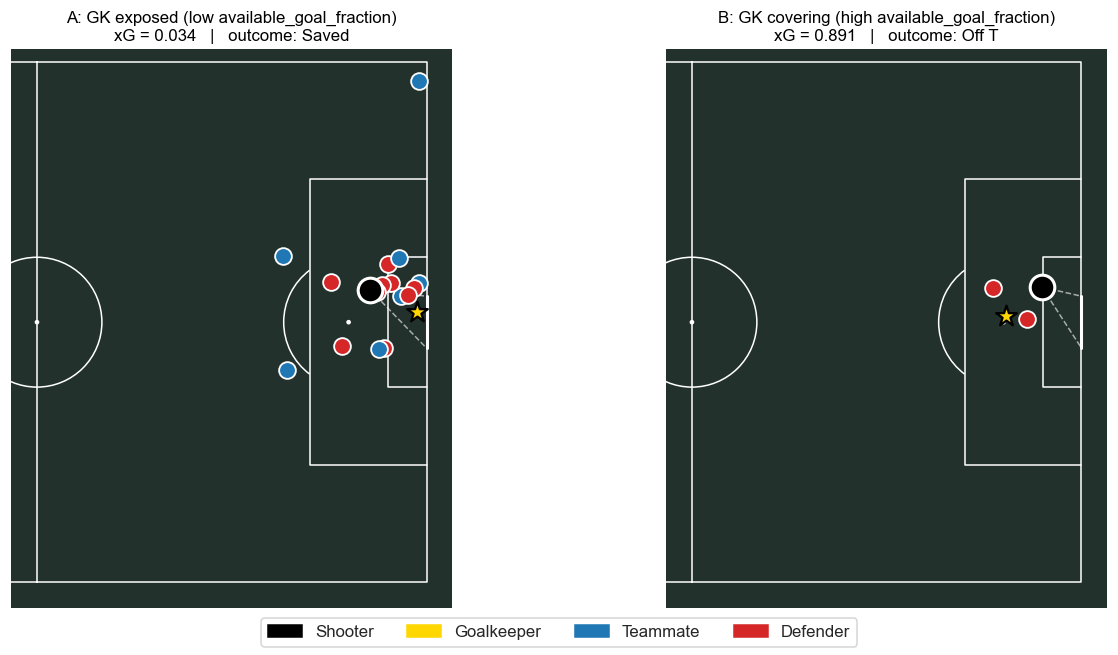

In [14]:
def draw_shot_situation(shot, ax, title=''):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white', linewidth=1, half=True, pad_top=2)
    pitch.draw(ax=ax)

    sx, sy = shot['location']
    gx, gy = shot['gk_location']

    for p in shot['shot.freeze_frame']:
        loc = p.get('location')
        if not loc:
            continue
        is_mate = p.get('teammate', False)
        is_gk   = p.get('position', {}).get('name') == 'Goalkeeper'
        if is_gk:
            continue
        color = '#1f77b4' if is_mate else '#d62728'
        pitch.scatter(loc[0], loc[1], ax=ax, s=120, c=color, edgecolors='white', linewidth=1.2, zorder=3)

    pitch.scatter(gx, gy, ax=ax, s=200, c='gold',
                  edgecolors='black', linewidth=1.5, marker='*', zorder=5,
                  label='GK')
    pitch.scatter(sx, sy, ax=ax, s=260, c='black',
                  edgecolors='white', linewidth=2, marker='o', zorder=6,
                  label='Shooter')

    pitch.lines(sx, sy, 120, 36, ax=ax, color='white', ls='--', lw=1.0, alpha=0.6, zorder=2)
    pitch.lines(sx, sy, 120, 44, ax=ax, color='white', ls='--', lw=1.0, alpha=0.6, zorder=2)

    outcome = shot['shot.outcome.name']
    ax.set_title(
        f'{title}\nxG = {shot["xg"]:.3f}   |   outcome: {outcome}',
        color='black', fontsize=11
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw_shot_situation(shot_lo, axes[0], title='A: GK exposed (low available_goal_fraction)')
draw_shot_situation(shot_hi, axes[1], title='B: GK covering (high available_goal_fraction)')

legend_patches = [
    mpatches.Patch(color='black',   label='Shooter'),
    mpatches.Patch(color='gold',    label='Goalkeeper'),
    mpatches.Patch(color='#1f77b4', label='Teammate'),
    mpatches.Patch(color='#d62728', label='Defender'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, frameon=True)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('figures/05_case_study_gk_pair.png', dpi=160, bbox_inches='tight')
plt.show()


## Model-prediction heatmap

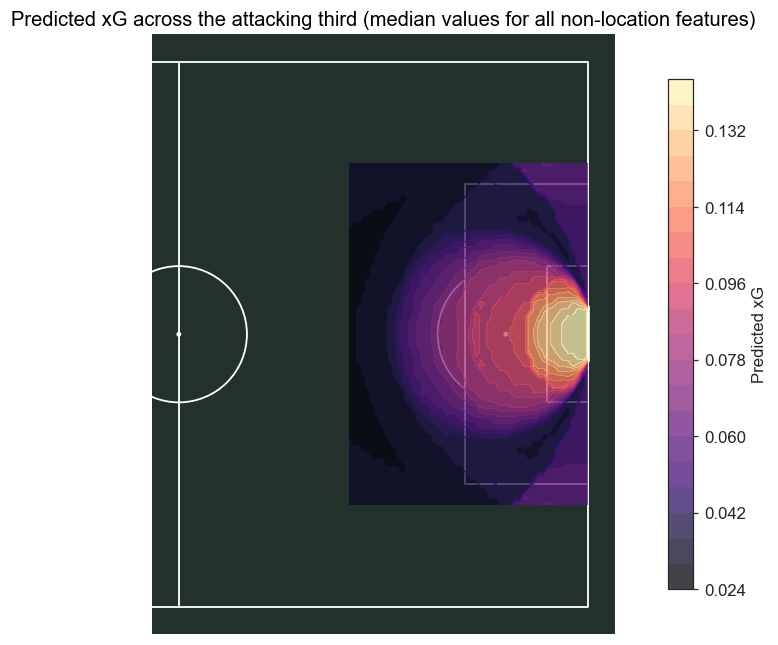

In [15]:
xs = np.linspace(85, 120, 50)
ys = np.linspace(15, 65, 50)
XX, YY = np.meshgrid(xs, ys)

template = test_pred[T12345].median().to_dict()

grid_rows = []
for x, y in zip(XX.ravel(), YY.ravel()):
    row = dict(template)
    
    row['distance_to_goal'] = float(np.hypot(120 - x, 40 - y))
    a = np.hypot([120, 120], [36, 44]) - 0
    
    al = np.hypot(120 - x, 36 - y)
    ar = np.hypot(120 - x, 44 - y)
    cos_a = (al**2 + ar**2 - 64) / (2*al*ar)
    row['angle_to_goal'] = float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))
    grid_rows.append(row)

grid = pd.DataFrame(grid_rows, columns=T12345)
ZZ = xgb_model.predict_proba(grid)[:, 1].reshape(XX.shape)

fig, ax = plt.subplots(figsize=(10, 6))
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white', linewidth=1.2, half=True)
pitch.draw(ax=ax)
cm = ax.contourf(XX, YY, ZZ, levels=20, cmap='magma', alpha=0.75)
cbar = fig.colorbar(cm, ax=ax, shrink=0.85, label='Predicted xG')
ax.set_title('Predicted xG across the attacking third (median values for all non-location features)', color='black')
plt.tight_layout()
plt.savefig('figures/05_xg_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

## BEST MODEL

In [16]:
best_row = best_per_model.iloc[0]
print('============================')
print('  HEADLINE FOR THE REPORT')
print('============================')
print(f'Dataset      : {len(df):,} shots ({df["goal"].mean():.1%} goal rate)')
print(f'Best model   : {best_row["model"]}')
print(f'Best tier    : {best_row["tier"]}')
print(f'AUC-ROC      : {best_row["auc_roc"]:.4f}')
print(f'Log loss     : {best_row["log_loss"]:.4f}')
print(f'Brier score  : {best_row["brier"]:.4f}\n')
print(f'Novel-tier contribution: {100*novel_gain/total_gain:.1f}% of total feature-engineering gain')

  HEADLINE FOR THE REPORT
Dataset      : 86,563 shots (10.1% goal rate)
Best model   : XGBoost (tuned)
Best tier    : Tier 1+2+3+4+5 (all)
AUC-ROC      : 0.8123
Log loss     : 0.2582
Brier score  : 0.0734

Novel-tier contribution: 42.5% of total feature-engineering gain
